### Exploratory Data Analysis (EDA)

This notebook focuses on understanding the e-commerce dataset before applying machine learning models.
As Member 01, I performed initial data exploration by analyzing the structure, identifying data types, checking for missing values, and visualizing both numerical and categorical features.

Key analyses include distribution of price and quantity, class distribution of delivery status and customer segments, and correlation between numerical variables. The insights obtained from this analysis help guide data preprocessing and model development in later stages of the project.

In [1]:
print("1_eda_and_preprocessing")

1_eda_and_preprocessing


In [5]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look better
sns.set_style('whitegrid')

In [9]:
# Load the dataset
df = pd.read_csv('../data/ecommerce_data.csv')

# show first 5 rows
df.head()

,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


In [10]:
# Basic Data Understanding

# shape of dataset
print("Shape:", df.shape)

# column names
print("Columns:", df.columns)

# data types and null values
df.info()

# statistical summary
df.describe()

Shape: (10000, 15)
Columns: Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'quantity', 'order_date', 'shipping_date', 'delivery_status',
       'payment_method', 'device_type', 'channel', 'shipping_address',
       'billing_address', 'customer_segment'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   customer_id       10000 non-null  int64  
 2   product_id        10000 non-null  int64  
 3   category          10000 non-null  object 
 4   price             10000 non-null  float64
 5   quantity          10000 non-null  int64  
 6   order_date        10000 non-null  object 
 7   shipping_date     10000 non-null  object 
 8   delivery_status   10000 non-null  object 
 9   payment_method    10000 non-null  object 
 10  device_type      

,customer_id,product_id,price,quantity
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,995.292300,504.872400,252.550681,2.124700
std,893.279854,288.281942,141.394146,1.254315
min,1.000000,1.000000,5.060000,1.000000
25%,182.000000,260.000000,130.607500,1.000000
50%,754.000000,507.000000,252.910000,2.000000
75%,1668.500000,752.000000,374.917500,3.000000
max,2999.000000,1000.000000,499.930000,9.000000


In [11]:
# Check Missing Values

df.isnull().sum()

order_id            0
customer_id         0
product_id          0
category            0
price               0
quantity            0
order_date          0
shipping_date       0
delivery_status     0
payment_method      0
device_type         0
channel             0
shipping_address    0
billing_address     0
customer_segment    0
dtype: int64

In [12]:
# Drop Unnecessary Columns

df = df.drop(columns=["order_id", "customer_id"], errors='ignore')

df.head()

,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


In [13]:
# Convert Dates

# convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])

# extract features
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day

# shipping time (days)
df['shipping_time'] = (df['shipping_date'] - df['order_date']).dt.days

df.head()

,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment,order_month,order_day,shipping_time
0,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP,4,20,7
1,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning,4,20,2
2,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning,4,20,7
3,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP,4,20,4
4,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP,4,20,5


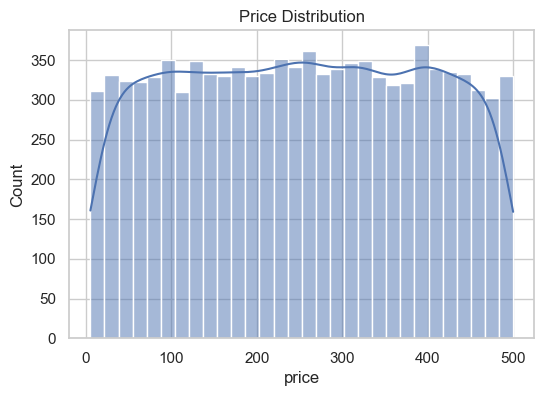

In [14]:
# Numerical Data Analysis

# price distribution

plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

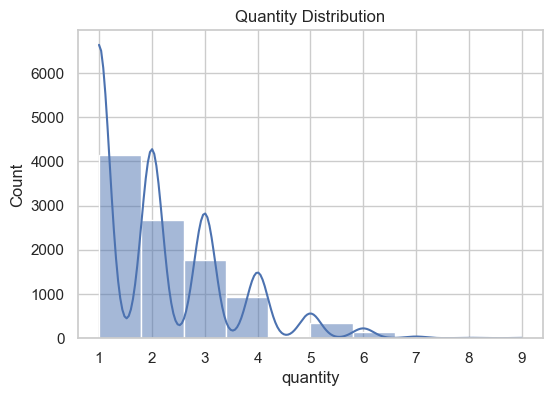

In [15]:
# Quantity Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['quantity'], bins=10, kde=True)
plt.title("Quantity Distribution")
plt.show()

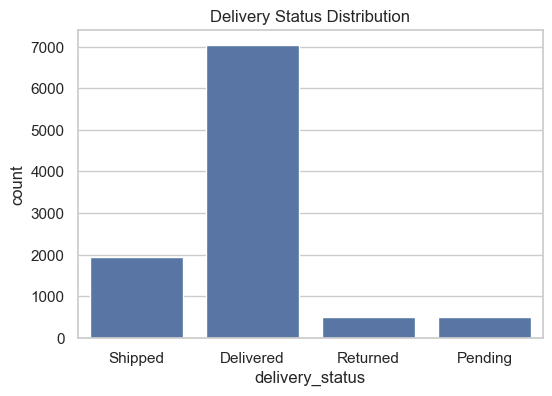

In [16]:
# Categorical Data Analysis

# Delivery Status

plt.figure(figsize=(6,4))
sns.countplot(x='delivery_status', data=df)
plt.title("Delivery Status Distribution")
plt.show()

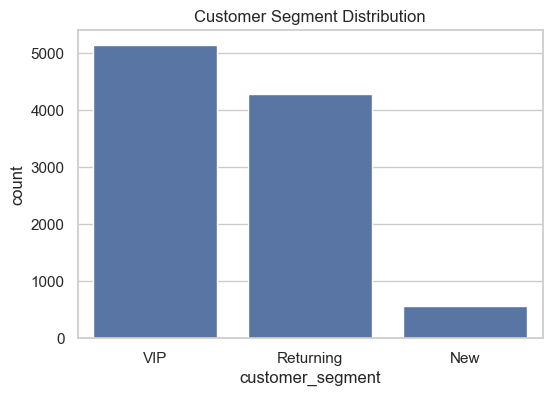

In [17]:
# Customer Segment

plt.figure(figsize=(6,4))
sns.countplot(x='customer_segment', data=df)
plt.title("Customer Segment Distribution")
plt.show()

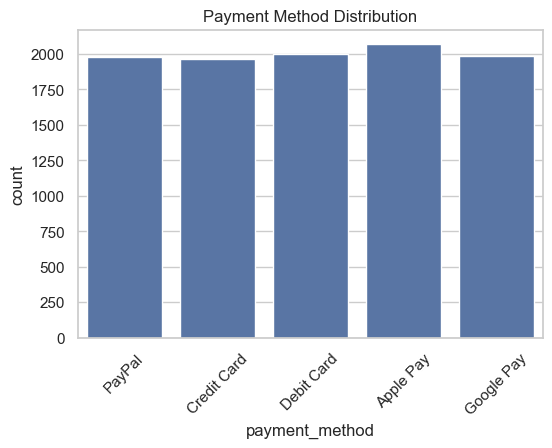

In [18]:
# Payment Method

plt.figure(figsize=(6,4))
sns.countplot(x='payment_method', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method Distribution")
plt.show()

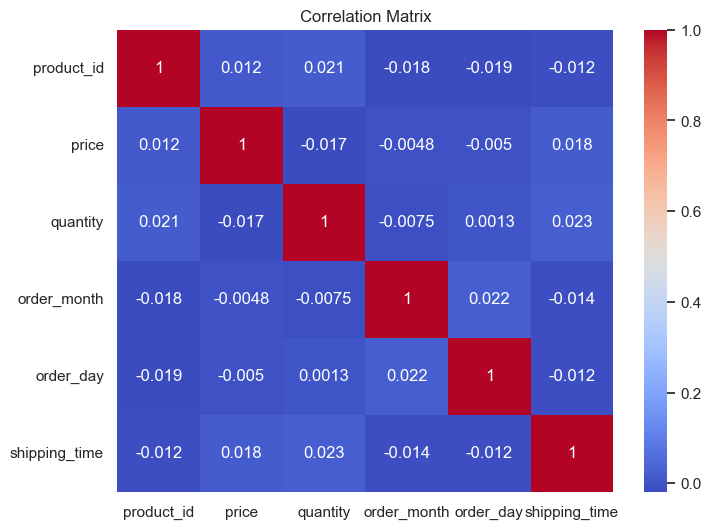

In [19]:
# Correlation Analysis

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

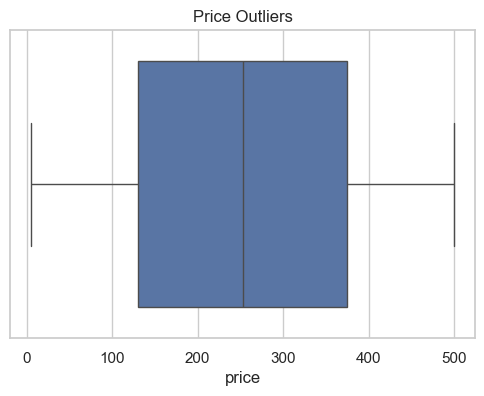

In [20]:
# Boxplot (Outliers)

plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()

### Key Findings:

- Most orders are "Delivered" → class imbalance exists
- Price is slightly right-skewed
- VIP customers are fewer compared to others
- Some outliers exist in price
- Shipping time varies across orders

In [22]:
# Save Clean Dataset

df.to_csv("../data/cleaned_data.csv", index=False)